In [27]:
!pip install numpy pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# =========================
# 1. IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [29]:
# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv('insurance_dataset.csv')
df.head()


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,city_type,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,80,Semi-Urban,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,64,Semi-Urban,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,0,Urban,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,70,Urban,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,77,Urban,3202.52


In [30]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   str    
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   str    
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   str    
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14  medication_count         5000 non-n

,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.299000,25.970820,0.207600,0.288000,0.14220,0.096400,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,57.953000,8048.886894
std,20.646851,5.046651,0.405629,0.452876,0.34929,0.295169,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,31.627742,7071.020228
min,18.000000,6.400000,0.000000,0.000000,0.00000,0.000000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,404.950000
25%,36.000000,22.600000,0.000000,0.000000,0.00000,0.000000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,53.000000,3241.977500
50%,53.000000,25.900000,0.000000,0.000000,0.00000,0.000000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,71.000000,5539.780000
75%,71.000000,29.400000,0.000000,1.000000,0.00000,0.000000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,79.000000,10094.097500
max,89.000000,43.600000,1.000000,1.000000,1.00000,1.000000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,44792.100000


In [31]:
df.isnull().sum()

age                        0
gender                     0
bmi                        0
smoker                     0
diabetes                   0
hypertension               0
heart_disease              0
asthma                     0
physical_activity_level    0
daily_steps                0
sleep_hours                0
stress_level               0
doctor_visits_per_year     0
hospital_admissions        0
medication_count           0
insurance_coverage_pct     0
city_type                  0
annual_medical_cost        0
dtype: int64

In [32]:
# =========================
# 3. PREPROCESSING + FEATURE ENGINEERING
# =========================
df = pd.get_dummies(df, drop_first=True)

#OUTLIER
#num_cols = ['age', 'bmi', 'annual_medical_cost']

#for col in num_cols:
#    Q1 = df[col].quantile(0.25)
 #   Q3 = df[col].quantile(0.75)
  #  IQR = Q3 - Q1                #jarak tengah data

  #  df = df[(df[col] >= (Q1 - 1.5 * IQR)) &
   #         (df[col] <= (Q3 + 1.5 * IQR))]



In [33]:
# =========================
# 5. SPLIT FITUR & TARGET
# =========================
X = df.drop('annual_medical_cost', axis=1)
y = df['annual_medical_cost']


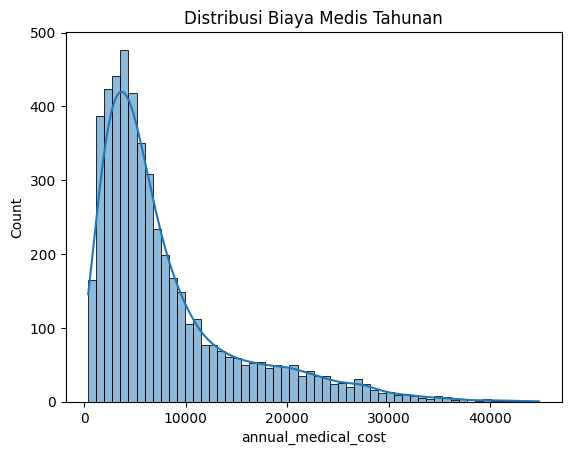

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['annual_medical_cost'], kde=True)
plt.title("Distribusi Biaya Medis Tahunan")
plt.show()

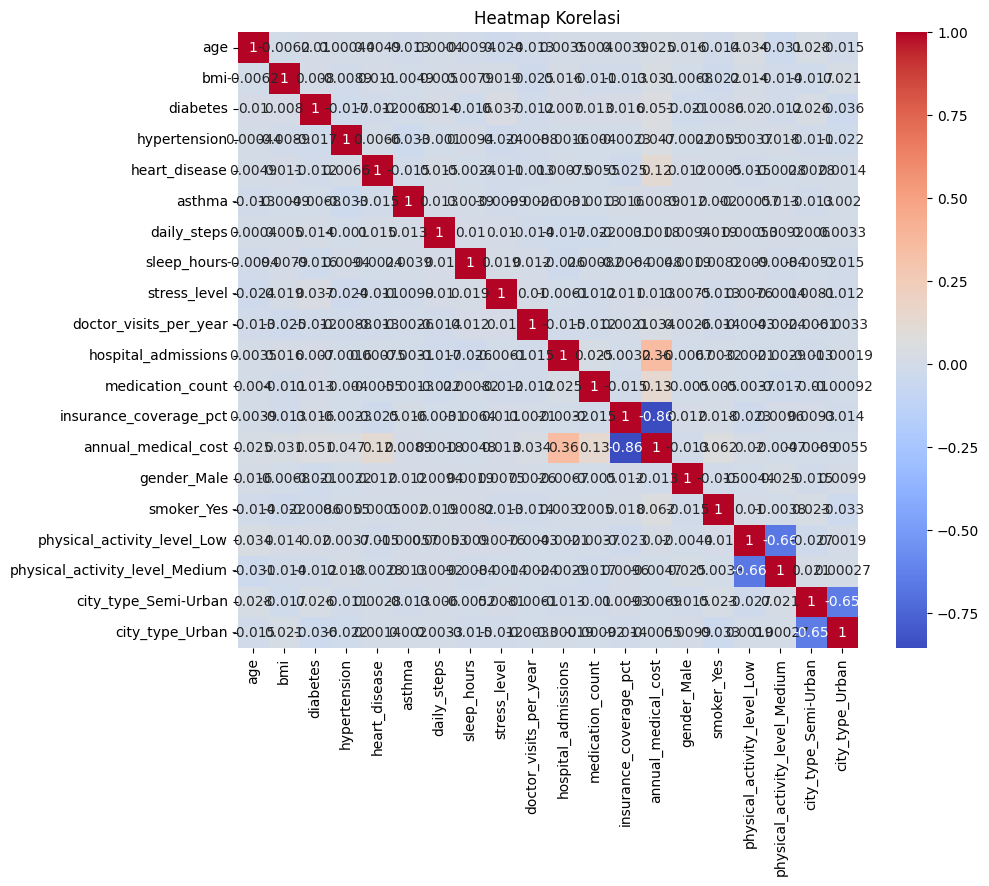

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi")
plt.show()

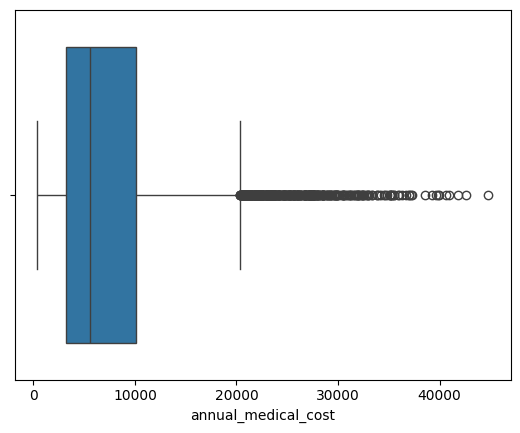

In [36]:
sns.boxplot(x=df['annual_medical_cost'])
plt.show()

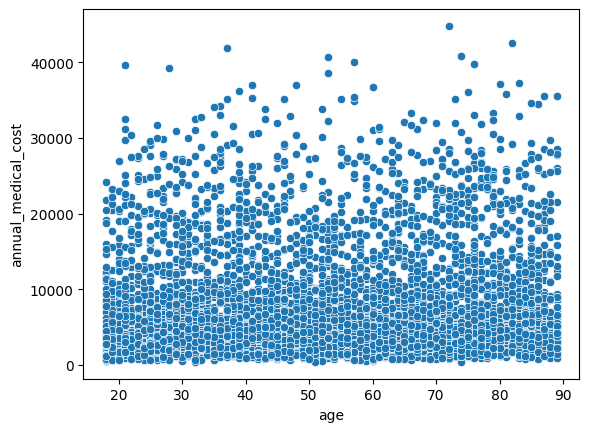

In [37]:
feature_example = df.columns[0]

sns.scatterplot(x=df[feature_example], y=df['annual_medical_cost'])
plt.show()

In [38]:
# =========================
# 7. SCALING
# =========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [39]:
# =========================
# 6. MODEL LIST
# =========================
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        random_state=42)
}

In [40]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

In [41]:
# =========================
# 7. RASIO SPLIT
# =========================
splits = {
    "70:30": 0.3,
    "80:20": 0.2,
    "90:10": 0.1
}

results = []

In [42]:


for split_name, test_size in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        train_pred = model.predict(X_train)

        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, y_pred)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)

        results.append({
            "Split": split_name,
            "Model": name,
            "Train R2": train_r2,
            "Test R2": test_r2,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse
        })

        print(f"\nSplit: {split_name} | Model: {name}")
        print(f"Train R2: {train_r2:.4f}")
        print(f"Test R2 : {test_r2:.4f}")
        print(f"MAE     : {mae:.2f}")
        print(f"MSE     : {mse:.2f}")
        print(f"RMSE    : {rmse:.2f}")


Split: 70:30 | Model: Linear Regression
Train R2: 0.8937
Test R2 : 0.9033
MAE     : 1530.09
MSE     : 4875997.31
RMSE    : 2208.17

Split: 70:30 | Model: Random Forest
Train R2: 0.9954
Test R2 : 0.9657
MAE     : 838.48
MSE     : 1731686.21
RMSE    : 1315.94

Split: 70:30 | Model: Gradient Boosting
Train R2: 0.9855
Test R2 : 0.9795
MAE     : 683.17
MSE     : 1032480.59
RMSE    : 1016.11

Split: 80:20 | Model: Linear Regression
Train R2: 0.8958
Test R2 : 0.9006
MAE     : 1529.55
MSE     : 4848675.54
RMSE    : 2201.97

Split: 80:20 | Model: Random Forest
Train R2: 0.9955
Test R2 : 0.9681
MAE     : 815.66
MSE     : 1554873.29
RMSE    : 1246.95

Split: 80:20 | Model: Gradient Boosting
Train R2: 0.9853
Test R2 : 0.9798
MAE     : 672.80
MSE     : 987522.86
RMSE    : 993.74

Split: 90:10 | Model: Linear Regression
Train R2: 0.8959
Test R2 : 0.9053
MAE     : 1473.93
MSE     : 4575879.88
RMSE    : 2139.13

Split: 90:10 | Model: Random Forest
Train R2: 0.9957
Test R2 : 0.9696
MAE     : 798.73
MS

In [43]:
results_df = pd.DataFrame(results)
results_df

,Split,Model,Train R2,Test R2,MAE,MSE,RMSE
0,70:30,Linear Regression,0.893718,0.903298,1530.093077,4.875997e+06,2208.166051
1,70:30,Random Forest,0.995366,0.965657,838.475527,1.731686e+06,1315.935488
2,70:30,Gradient Boosting,0.985493,0.979524,683.173667,1.032481e+06,1016.110519
3,80:20,Linear Regression,0.895803,0.900594,1529.552853,4.848676e+06,2201.970831
4,80:20,Random Forest,0.995504,0.968122,815.656958,1.554873e+06,1246.945583
5,80:20,Gradient Boosting,0.985293,0.979754,672.800473,9.875229e+05,993.741850
6,90:10,Linear Regression,0.895882,0.905338,1473.933362,4.575880e+06,2139.130638
7,90:10,Random Forest,0.995715,0.969583,798.727683,1.470346e+06,1212.578338
8,90:10,Gradient Boosting,0.984982,0.981192,653.895512,9.091744e+05,953.506360


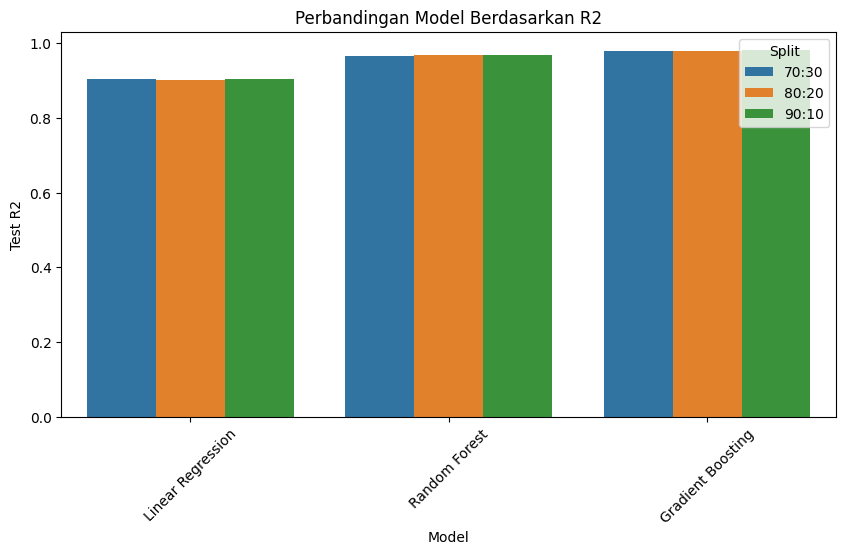

In [44]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="Test R2", hue="Split")
plt.title("Perbandingan Model Berdasarkan R2")
plt.xticks(rotation=45)
plt.show()

In [ ]:
## tambahkan inferencee

# =========================
# INFERENCE (DATA BARU)
# =========================

#data baru kategori biaya rendah
data_baru_1 = pd.DataFrame({
    "age": [30],
    "gender": ["Male"],
    "bmi": [28.5],
    "smoker": ["No"],
    "diabetes": ["Yes"],
    "hypertension": ["No"],
    "heart_disease": ["No"],
    "asthma": ["Yes"],
    "physical_activity_level": ["Medium"],
    "daily_steps": [6000],
    "sleep_hours": [6],
    "stress_level": ["Medium"],
    "doctor_visits_per_year": [3],
    "hospital_admissions": [1],
    "medication_count": [2],
    "insurance_coverage_pct": [75],
    "city_type": ["Urban"]
    })

In [ ]:
#data baru ktegori biaya sedang
data_baru_2 = pd.DataFrame({
    "age": [38],
    "gender": ["Male"],
    "bmi": [26.5],
    "smoker": ["No"],
    "diabetes": ["No"],
    "hypertension": ["Yes"],
    "heart_disease": ["No"],
    "asthma": ["Yes"],
    "physical_activity_level": ["Low"],
    "daily_steps": [4000],
    "sleep_hours": [6],
    "stress_level": ["High"],
    "doctor_visits_per_year": [5],
    "hospital_admissions": [1],
    "medication_count": [2],
    "insurance_coverage_pct": [70],
    "city_type": ["Semi-Urban"]
})

In [ ]:
#data baru kategori biaya tinggi
data_baru_3 = pd.DataFrame({
    "age": [70],
    "gender": ["Male"],
    "bmi": [33.0],
    "smoker": ["Yes"],
    "diabetes": ["Yes"],
    "hypertension": ["Yes"],
    "heart_disease": ["Yes"],
    "asthma": ["Yes"],
    "physical_activity_level": ["Low"],
    "daily_steps": [1500],
    "sleep_hours": [5],
    "stress_level": ["High"],
    "doctor_visits_per_year": [12],
    "hospital_admissions": [4],
    "medication_count": [10],
    "insurance_coverage_pct": [40],
    "city_type": ["Urban"]
})

In [48]:

data_baru_all = pd.concat([data_baru_1, data_baru_2, data_baru_3], ignore_index=True)

# encoding
data_baru_all = pd.get_dummies(data_baru_all, drop_first=True)

# Samakan kolom dengan X
data_baru_all = data_baru_all.reindex(columns=df.drop('annual_medical_cost', axis=1).columns, fill_value=0)

# Scaling
data_baru_scaled = scaler.transform(data_baru_all)

# Gunakan model (Random Forest)
model_terbaik = RandomForestRegressor(n_estimators=500, random_state=42)
model_terbaik.fit(X_train, y_train)

#Prediksi
hasil = model_terbaik.predict(data_baru_scaled)

print("\n=== HASIL INFERENCE ===")
for i, h in enumerate(hasil):
    print(f"Data {i+1}: {h:.2f}")


=== HASIL INFERENCE ===
Data 1: 3980.98
Data 2: 4832.16
Data 3: 16449.01


In [49]:
import pickle

pickle.dump(model_terbaik, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))